In [15]:
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt
import pandas as pd

Import and analyse noise dataset

In [16]:
noise_streets = gpd.read_file("../../layers/BCN_noise_streets.gpkg")
noise_streets['fid'] = noise_streets.index # Assign explicitly a numeric FID
print(noise_streets.crs)  #CRS = Coordinate Reference System
print(noise_streets.shape)
print(noise_streets.columns.tolist())
print("Number of street segments:", len(noise_streets))

EPSG:25831
(15115, 31)
['TRAM', 'TOTAL_D', 'TOTAL_E', 'TOTAL_N', 'TOTAL_DEN', 'TRANSIT_D', 'TRANSIT_E', 'TRANSIT_N', 'TRANSIT_DEN', 'GI_TR_D', 'GI_TR_E', 'GI_TR_N', 'GI_TR_DEN', 'FFCC_D', 'FFCC_E', 'FFCC_N', 'FFCC_DEN', 'INDUST_D', 'INDUST_E', 'INDUST_N', 'INDUST_DEN', 'VIANANTS_D', 'VIANANTS_E', 'OCI_N', 'PATIS_D', 'PATIS_E', 'geometry_type', 'start', 'end', 'geometry', 'fid']
Number of street segments: 15115


Roads - OSM

In [17]:
roads = ox.features_from_place("Barcelona, Spain", tags={"highway": True}) #connects to OSM and downloads all features within Barcelona that match the tags you specify
roads = roads[roads.geometry.type == 'LineString'].to_crs(noise_streets.crs) #keeps only line geometries and reprojects to match the CRS of noise_streets (otherwise they come in EPSG:4326)
print(roads.crs)
print(roads.columns.tolist())

EPSG:25831
['geometry', 'highway', 'traffic_signals', 'traffic_signals:direction', 'button_operated', 'crossing', 'tactile_paving', 'traffic_signals:sound', 'traffic_signals:vibration', 'crossing:markings', 'crossing:signals', 'kerb', 'supervised', 'crossing:island', 'bicycle', 'source', 'traffic_signals:arrow', 'name', 'direction', 'loc_name', 'maxspeed', 'note', 'operator', 'check_date:crossing', 'source:date', 'ref', 'bench', 'bus', 'network', 'passenger_information_display', 'public_transport', 'route_ref', 'shelter', 'traffic_calming', 'speed_camera:direction', 'noref', 'noname', 'distance', 'bin', 'lit', 'name:ca', 'foot', 'destination:ref', 'traffic_sign', 'colour:ref', 'railway', 'wheelchair', 'url', 'side', 'network:short', 'network:wikidata', 'check_date:traffic_signals:sound', 'surface', 'check_date:shelter', 'website', 'alt_name', 'kerb:approach_aid', 'passenger_information_display:speech_output', 'description', 'check_date:tactile_paving', 'barrier', 'network:bus', 'networ

<Axes: >

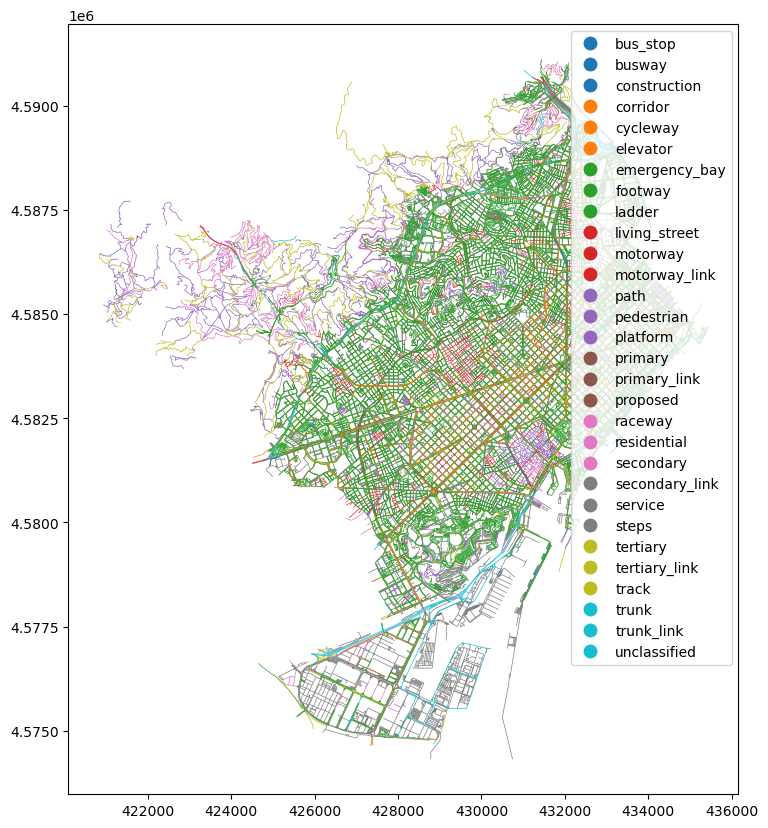

In [18]:
roads.plot(figsize=(10, 10), column='highway', linewidth=0.5, legend=True)

#https://osmnx.readthedocs.io/en/stable/user-reference.html#osmnx.features.features_from_place

Filter roads categories

Original: 80662, Filtered: 15868


<Axes: >

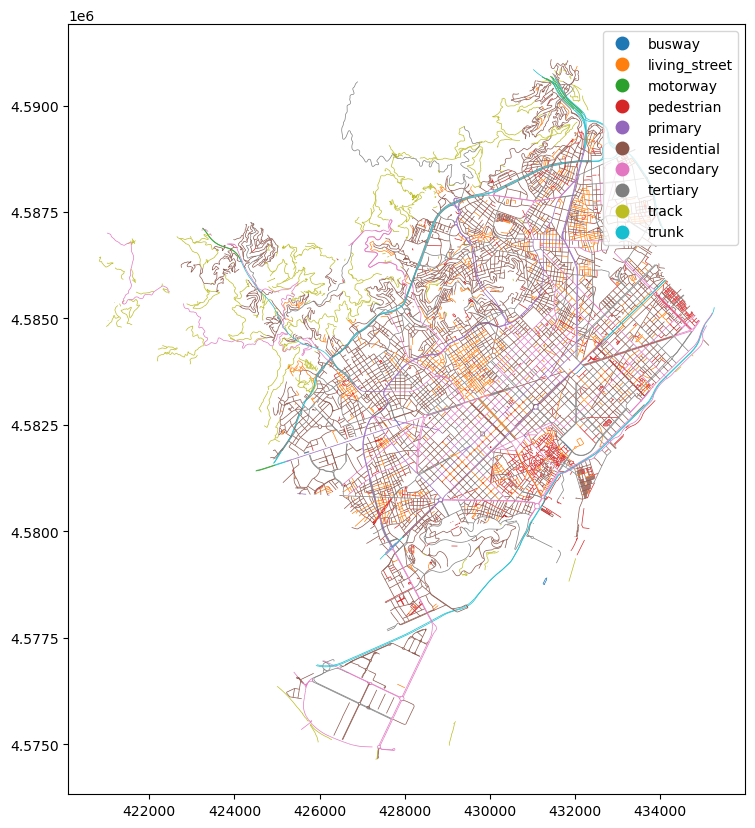

In [19]:
# Filter to only primary and secondary roads
categories = ['busway', 'living_street','motorway','pedestrian','residential','primary', 'secondary', 'tertiary', 'trunk', 'track']
roads_filtered = roads[roads['highway'].isin(categories)]
print(f"Original: {len(roads)}, Filtered: {len(roads_filtered)}")
roads_filtered.plot(figsize=(10, 10), column='highway', linewidth=0.5, legend=True)

Assign to noise street the category of the closest osm road

In [20]:
# Find the nearest road for each noise street segment
print(f"Original noise_streets: {noise_streets.shape}")
# Reset index before spatial join
noise_streets_clean = noise_streets[['fid', 'TRAM', 'geometry','TOTAL_D','TOTAL_E','TOTAL_N']].reset_index(drop=False)
roads_clean = roads_filtered[['geometry', 'highway']].reset_index(drop=True)

dataset = gpd.sjoin_nearest(
    noise_streets_clean, 
    roads_clean,
    how='left'
)

# Now filter to keep only one row per street_id if needed
dataset = dataset.drop_duplicates(subset=['index'], keep='first')
print(f"Noise streets after nearest road join: {dataset.shape}")
print(dataset.columns.tolist())

Original noise_streets: (15115, 31)
Noise streets after nearest road join: (15115, 9)
['index', 'fid', 'TRAM', 'geometry', 'TOTAL_D', 'TOTAL_E', 'TOTAL_N', 'index_right', 'highway']


Create data frame

In [21]:
dataset = pd.DataFrame({
    "fid": dataset['fid'],
    "street_id": dataset['TRAM'],
    "noise_day": dataset['TOTAL_D'],
    "noise_evening": dataset['TOTAL_E'],
    "noise_night": dataset['TOTAL_N'],
    "road_category": dataset['highway']    
}).fillna(0) #fillna(0) to replace any NaN values (which indicate no signals or POIs in that segment) with 0

# Export to match other feature pipelines
import os
output_dir = "../../data/processed"
os.makedirs(output_dir, exist_ok=True)
dataset.to_csv(os.path.join(output_dir, "osm_roads_features.csv"), index=False)
print("Exported osm_roads_features.csv")

display(dataset.head(10))

Exported osm_roads_features.csv


,fid,street_id,noise_day,noise_evening,noise_night,road_category
0,0,T04719W,70 - 75 dB(A),65 - 70 dB(A),60 - 65 dB(A),residential
1,1,T19941Z,45 - 50 dB(A),45 - 50 dB(A),< 40 dB(A),pedestrian
2,2,T18111R,55 - 60 dB(A),55 - 60 dB(A),50 - 55 dB(A),residential
3,3,T03222Y,60 - 65 dB(A),55 - 60 dB(A),60 - 65 dB(A),living_street
4,4,T17625I,55 - 60 dB(A),55 - 60 dB(A),50 - 55 dB(A),residential
5,5,T05360P,55 - 60 dB(A),55 - 60 dB(A),50 - 55 dB(A),residential
6,6,T08863T,50 - 55 dB(A),50 - 55 dB(A),45 - 50 dB(A),residential
7,7,T00236S,45 - 50 dB(A),45 - 50 dB(A),40 - 45 dB(A),residential
8,8,T13009A,55 - 60 dB(A),55 - 60 dB(A),50 - 55 dB(A),residential
9,9,T11921P,60 - 65 dB(A),55 - 60 dB(A),50 - 55 dB(A),residential


TODO: add more info from roads 